# PVGIS-only ST-GNN — Monaco neural-SDE (drift/diffusion) pipeline

Reproducible orchestrator for the final run on server **newzealand**.

Does **not** duplicate runner/analysis logic — it builds commands and reads the
CSVs they write, via `physiq_pv.experiments.sde_pipeline`.

Safety switches: `RUN_TRAINING`, `RUN_ANALYSIS`, `RUN_SWEEP`, `CREATE_SWEEP`, `LOG_TO_WANDB`.

## 1. Setup

In [2]:
import os, sys, subprocess
from pathlib import Path
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
os.environ['PYTHONPATH'] = str(REPO_ROOT) + os.pathsep + os.environ.get('PYTHONPATH', '')
os.chdir(REPO_ROOT)

from physiq_pv.experiments import sde_pipeline as pipe
print('repo root:', REPO_ROOT)

repo root: /home/apedalino/physiq_pv


In [3]:
PVGIS_DIR = pipe.PVGIS_DIR
TEST_ANOMALY_SCORES = pipe.TEST_ANOMALY_SCORES
TRAIN_ANOMALY_SCORES = pipe.TRAIN_ANOMALY_SCORES
ANALYSIS_SCRIPT = pipe.ANALYSIS_SCRIPT

checks = {
    'PVGIS dir': Path(PVGIS_DIR).is_dir(),
    'test anomaly scores': Path(TEST_ANOMALY_SCORES).exists(),
    'train anomaly scores': Path(TRAIN_ANOMALY_SCORES).exists(),
    'analysis script': Path(ANALYSIS_SCRIPT).exists(),
}
try:
    import physiq_pv.experiments.pvgis_stgnn_runner  # noqa: F401
    checks['runner importable'] = True
except Exception as e:
    checks['runner importable'] = False
    print('runner import error:', e)
for k, v in checks.items():
    print(('OK     ' if v else 'MISSING') + '  ' + k)

OK       PVGIS dir
OK       test anomaly scores
OK       train anomaly scores
OK       analysis script
OK       runner importable


If the anomaly scores are **missing**, regenerate them (run in a terminal — not launched automatically):

In [5]:
if not (Path(TEST_ANOMALY_SCORES).exists() and Path(TRAIN_ANOMALY_SCORES).exists()):
    base = ('PYTHONPATH=$PWD python scripts/run_pvgis_climatology_anomaly_years.py'
            ' --pvgis-dir ' + PVGIS_DIR +
            ' --climatology-start-year 2005 --climatology-end-year 2023'
            ' --quantile 0.975 --climatology-window-days 15 --min-climatology-years 3'
            ' --variables solar_irradiance_poa pv_power_output temperature_2m wind_speed_10m'
            ' --out-root outputs')
    print('# Test year 2019:')
    print(base + ' --years 2019')
    print()
    print('# Train years 2016-2018 (aggregated):')
    print(base + ' --years 2016,2017,2018 --aggregate-out-dir ' + str(Path(TRAIN_ANOMALY_SCORES).parent))
else:
    print('anomaly scores present.')

anomaly scores present.


## 2. Single-run config

In [ ]:
# === EXPERIMENT SELECTOR ===
# beta_nll   = Kong-faithful (train on ALL cells) + beta-NLL (Seitzer 2022,
#              beta_nll=0.5 from DEFAULT_CONFIG) to stop the variance runaway
#              that under-fits the mean. This is the current main run.
# kong_all   = plain Kong NLL on all cells (no beta-NLL) — the under-fit baseline.
# normal_only= label-defined ablation: optimise only on normal target/history
#              cells (NOT Kong: it holds rare out of the loss).
# student_t* = beta_nll + Student-t likelihood (heavier tails -> better tail
#              coverage at 95/99%). nll_dist=student_t, student_t_nu sweeps the
#              degrees of freedom (smaller = heavier tails; nu->inf == Gaussian).
EXPERIMENT = 'beta_nll'   # 'beta_nll' | 'kong_all' | 'baseline' | 'exp1' | 'exp2' | 'normal_only' | 'student_t' | 'student_t_nu3' | 'student_t_nu10'

_OVERRIDES = {
    'baseline': {},
    'exp1': {'epochs': 20, 'name': 'ep20'},
    'exp2': {'epochs': 20, 'n_sde_steps': 8, 'sigma_max': 2.0, 'name': 'sde8_sm2p0_ep20'},
    # Kong-faithful + beta-NLL (beta_nll=0.5 inherited from DEFAULT_CONFIG).
    'beta_nll': {'epochs': 10, 'train_normal_only': False, 'name': 'beta_nll_ep10'},
    # Plain Kong NLL, all data (beta_nll=0 to disable beta-NLL).
    'kong_all': {'epochs': 10, 'train_normal_only': False, 'beta_nll': 0.0, 'name': 'kong_all_ep10'},
    # Requires TRAIN-year anomaly scores to select normal target/history cells.
    'normal_only': {'epochs': 10, 'train_normal_only': True, 'name': 'normal_only_ep10'},
    # beta-NLL + Student-t likelihood (heavy tails). PI uses the t-quantile.
    'student_t': {'epochs': 10, 'train_normal_only': False,
                  'nll_dist': 'student_t', 'student_t_nu': 5.0,
                  'name': 'student_t_nu5_ep10'},
    'student_t_nu3': {'epochs': 10, 'train_normal_only': False,
                      'nll_dist': 'student_t', 'student_t_nu': 3.0,
                      'name': 'student_t_nu3_ep10'},
    'student_t_nu10': {'epochs': 10, 'train_normal_only': False,
                       'nll_dist': 'student_t', 'student_t_nu': 10.0,
                       'name': 'student_t_nu10_ep10'},
}

BASE_CONFIG = {**pipe.DEFAULT_CONFIG, **_OVERRIDES[EXPERIMENT]}

out_dir = pipe.make_out_dir(BASE_CONFIG)
run_name = pipe.make_run_name(BASE_CONFIG)
print('experiment:', EXPERIMENT)
print('config    :', BASE_CONFIG)
print('out_dir   :', out_dir)
print('run_name  :', run_name)
if Path(out_dir).exists():
    print('WARNING: out_dir already exists — a run would overwrite its files.')

## 3. Training command

In [5]:
train_cmd = pipe.build_train_command(
    BASE_CONFIG, out_dir=out_dir, run_name=run_name,
    pvgis_dir=PVGIS_DIR, test_anomaly_scores=TEST_ANOMALY_SCORES,
    train_anomaly_scores=TRAIN_ANOMALY_SCORES, device='cuda', use_wandb=True)
print(' \\\n  '.join(train_cmd))

/home/apedalino/physiq_pv/.venv/bin/python \
  -m \
  physiq_pv.experiments.pvgis_stgnn_runner \
  --pvgis-dir \
  /data/SentinelPV/pvgis_data/data/pvgis_summed_irradiance \
  --anomaly-scores \
  outputs/pvgis_anomaly_2019_2005_2023_w15_q0975/pvgis_climatology_scores.csv \
  --train-years \
  2016,2017,2018 \
  --test-year \
  2019 \
  --seq-len \
  24 \
  --horizon \
  1 \
  --target-variable \
  pv_power_output \
  --model-type \
  stgnn \
  --feature-set \
  full \
  --irradiance-loss-weight \
  0.1 \
  --epochs \
  10 \
  --batch-size \
  16 \
  --lr \
  0.001 \
  --lr-g \
  0.01 \
  --beta-nll \
  0.5 \
  --dropout \
  0.3 \
  --mc-samples \
  10 \
  --pv-target-clip-max \
  none \
  --seed \
  1 \
  --n-sde-steps \
  4 \
  --sigma-max \
  0.5 \
  --sde-sigma-initial \
  0.1 \
  --sde-sigma-warmup-epochs \
  2 \
  --ood-noise-std \
  2.0 \
  --use-irradiance-head \
  --use-irradiance-loss \
  --sde-uncertainty \
  --device \
  cuda \
  --out-dir \
  outputs/pvgis_stgnn_beta_nll_e

## 4. Run training

Set `RUN_TRAINING = True` to actually launch.

In [6]:
RUN_TRAINING = True

if RUN_TRAINING:
    subprocess.run(train_cmd, check=True)
else:
    print('RUN_TRAINING is False — not launching. Command above is what would run.')

INFO: paper-style protocol — two-source uncertainty (Kong et al. 2020): epistemic = Var of the SDE Brownian-path predictive means, aleatoric = mean of the Gaussian PV head variance. The primary interval (lower_pi/upper_pi) is the Gaussian band mean +/- z * total_std with total_std^2 = epistemic^2 + aleatoric^2. 


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/apedalino/.netrc.
wandb: Currently logged in as: albertopedalino (albertopedalino-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run 9ckwr3uh
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /home/apedalino/physiq_pv/wandb/run-20260622_200416-9ckwr3uh
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run pvgis_stgnn_beta_nll_ep10_seed1
wandb: ⭐️ View project at https://wandb.ai/albertopedalino-politecnico-di-torino/PhysiQ-PV
wandb: 🚀 View run at https://wandb.ai/albertopedalino-politecnico-di-torino/PhysiQ-PV/runs/9ckwr3uh


[wandb] run id=9ckwr3uh name=pvgis_stgnn_beta_nll_ep10_seed1 -> out_dir=outputs/pvgis_stgnn_beta_nll_ep10_seed1
[wandb] run metadata -> outputs/pvgis_stgnn_beta_nll_ep10_seed1/wandb_run.json
[config] seed=1  batch_size=16  epochs=10  mc_samples=10  skip_predictions_csv=False  train_years=2016,2017,2018  test_year=2019  pv_target_clip_max=None  n_sde_steps=4  sigma_max=0.5  sde_sigma_initial=0.1  sde_sigma_warmup_epochs=2  ood_noise_std=2.0  lr_g=0.01  use_irradiance_head=True  use_irradiance_loss=True  irradiance_loss_weight=0.1  out_dir=outputs/pvgis_stgnn_beta_nll_ep10_seed1
[1/6] Loading PVGIS years (train=[2016, 2017, 2018], test=2019) | model=stgnn feature_set=full n_features=11
  [ok]   loaded PVGIS year 2016: piedmont_pvgis_2016.nc
  [ok]   loaded PVGIS year 2017: piedmont_pvgis_2017.nc
  [ok]   loaded PVGIS year 2018: piedmont_pvgis_2018.nc
[2/6] Building datasets (features=['temperature_2m', 'solar_irradiance_poa', 'wind_speed_10m', 'sin_elev', 'cos_elev', 'kt', 'kt_std_3h', '

wandb: updating run metadata; uploading artifact pvgis-stgnn-report-9ckwr3uh
wandb: uploading artifact pvgis-stgnn-report-9ckwr3uh
wandb: uploading history steps 10-10, summary, console lines 37-648
wandb: 
wandb: Run history:
wandb:              clc_gaussian/daytime ▁
wandb: clc_gaussian/extreme_peak_daytime ▁
wandb:               clc_gaussian/global ▁
wandb:         clc_gaussian/high_daytime ▁
wandb:            clc_gaussian/nighttime ▁
wandb:               clc_gaussian/normal ▁
wandb:       clc_gaussian/normal_daytime ▁
wandb:     clc_gaussian/normal_nighttime ▁
wandb:         clc_gaussian/peak_daytime ▁
wandb:         clc_gaussian/rare_extreme ▁
wandb:                              +591 ...
wandb: 
wandb: Run summary:
wandb:              clc_gaussian/daytime 0.60611
wandb: clc_gaussian/extreme_peak_daytime 0.49121
wandb:               clc_gaussian/global 0.25339
wandb:         clc_gaussian/high_daytime 0.59081
wandb:            clc_gaussian/nighttime 0.01267
wandb:               clc_

## 5. Post-hoc analysis

In [7]:
RUN_ANALYSIS = True

analysis_cmd = pipe.build_analysis_command(out_dir, BASE_CONFIG)
print(' \\\n  '.join(analysis_cmd))
if RUN_ANALYSIS:
    subprocess.run(analysis_cmd, check=True)
else:
    print('RUN_ANALYSIS is False — not launching.')

/home/apedalino/physiq_pv/.venv/bin/python \
  scripts/analyze_pvgis_daytime_report.py \
  --predictions \
  outputs/pvgis_stgnn_beta_nll_ep10_seed1/predictions.csv \
  --out-dir \
  outputs/pvgis_stgnn_beta_nll_ep10_seed1 \
  --epochs \
  10 \
  --dropout \
  0.3 \
  --mc-samples \
  10
[load] scanned 10,037,664 rows; 4,747,545 daytime candidates (solar > 10.0 W/m^2); kept 4,747,545 valid, skipped 0 invalid; 5,290,119 nighttime
[sharpness] target_range = 891.8600 (y_true_min 1.4100, y_true_max 893.2700)
[done] wrote:
  outputs/pvgis_stgnn_beta_nll_ep10_seed1/daytime_bin_anomaly_report.md
  outputs/pvgis_stgnn_beta_nll_ep10_seed1/daytime_anomaly_overview.csv
  outputs/pvgis_stgnn_beta_nll_ep10_seed1/daytime_bin_summary.csv
  outputs/pvgis_stgnn_beta_nll_ep10_seed1/daytime_bin_anomaly_metrics.csv
  outputs/pvgis_stgnn_beta_nll_ep10_seed1/uncertainty_response.csv
  outputs/pvgis_stgnn_beta_nll_ep10_seed1/sharpness_overview.csv


## 6. Results & figures

Reads the CSVs the runner/analysis wrote, then shows: summary tables, the
SDE band (predictive std) by anomaly group, and the post-hoc figures
(histograms + boxplots). Monaco SDE U-Net: one total uncertainty band
(SDE-sample spread), no aleatoric/epistemic split.

In [8]:
def _read(name):
    p = Path(out_dir) / name
    return pd.read_csv(p) if p.exists() else None

RESULT_FILES = ['metrics_global.csv','metrics_daytime.csv','metrics_by_anomaly_label.csv',
                'residual_bias_and_bin_metrics.csv','daytime_bin_summary.csv',
                'daytime_bin_anomaly_metrics.csv','uncertainty_response.csv','sharpness_overview.csv']
results = {n: _read(n) for n in RESULT_FILES}
for n, df in results.items():
    print((('OK  ' if df is not None else '--  ') + n) + (('  ' + str(df.shape)) if df is not None else ''))

OK  metrics_global.csv  (1, 9)
OK  metrics_daytime.csv  (12, 26)
OK  metrics_by_anomaly_label.csv  (6, 9)
OK  residual_bias_and_bin_metrics.csv  (19, 24)
OK  daytime_bin_summary.csv  (6, 8)
OK  daytime_bin_anomaly_metrics.csv  (36, 9)
OK  uncertainty_response.csv  (5, 8)
OK  sharpness_overview.csv  (7, 10)


In [9]:
sharp = results['sharpness_overview.csv']
if sharp is not None:
    cols = [c for c in ['scope','count','picp','mae','rmse','mean_std','mpiw','nmpil'] if c in sharp.columns]
    display(sharp[cols])
bins = results['daytime_bin_summary.csv']
if bins is not None:
    display(bins)
unc = results['uncertainty_response.csv']
if unc is not None:
    display(unc)

,scope,count,picp,mae,rmse,mean_std,mpiw,nmpil
0,overall_daytime,4747545,0.933653,47.669416,72.798089,63.989082,250.832591,0.281247
1,normal,4195053,0.933151,46.970544,71.286183,63.906978,250.510750,0.280886
2,rare_extreme,552492,0.937465,52.975924,83.388410,64.612494,253.276320,0.283987
3,unusually_low_solar_potential,99535,0.932727,81.169251,119.605028,69.736936,273.363767,0.306510
4,unusually_high_solar_potential,38401,0.975600,47.076240,75.607902,68.533728,268.647279,0.301221
5,extreme_temperature_condition,238447,0.950492,42.237161,65.059651,61.650025,241.663656,0.270966
6,extreme_wind_condition,221945,0.925216,54.822914,83.526888,67.813781,265.825138,0.298057


,bin,count,mae,rmse,picp,mean_std,mpiw,nmpil
0,daytime_0_20,396207,13.475683,26.264667,0.956162,18.480386,72.441782,0.081226
1,daytime_20_40,376626,30.044677,50.883162,0.917799,34.211430,134.106343,0.150367
2,daytime_40_60,352255,43.108868,71.408823,0.888254,46.053859,180.527809,0.202417
3,daytime_60_80,266151,51.553448,79.303798,0.875003,55.425243,217.262959,0.243607
4,daytime_80_100,206451,52.961063,79.568277,0.873055,60.411163,236.807408,0.265521
5,daytime_gt_100,3149855,53.912878,77.940174,0.946722,76.237777,298.846593,0.335082


,category,mae_ratio_vs_normal,rmse_ratio_vs_normal,std_ratio_vs_normal,picp_delta_vs_normal,mpiw_ratio_vs_normal,nmpil_ratio_vs_normal,underdispersion_flag
0,rare_extreme,1.127854,1.169770,1.011040,0.004314,1.011040,1.011040,True
1,unusually_low_solar_potential,1.728088,1.677815,1.091226,-0.000424,1.091226,1.091226,True
2,unusually_high_solar_potential,1.002250,1.060625,1.072398,0.042448,1.072398,1.072398,False
3,extreme_temperature_condition,0.899227,0.912654,0.964684,0.017341,0.964684,0.964684,False
4,extreme_wind_condition,1.167176,1.171712,1.061133,-0.007936,1.061133,1.061133,True


In [10]:
# SDE band (total predictive std) by anomaly group. Monaco does not split
# aleatoric/epistemic: the band is the spread of the SDE samples. Seasonal
# anomaly labels are evaluation strata only.
_pred = Path(out_dir) / 'predictions.csv'
if _pred.exists():
    _df = pd.read_csv(_pred, usecols=['anomaly_group', 'solar_irradiance_poa_target',
                                      'y_pred_std'])
    _day = _df[_df['solar_irradiance_poa_target'] > 10.0]
    display(_day.groupby('anomaly_group')[['y_pred_std']].mean())
else:
    print('predictions.csv not found — run training first.')

,y_pred_std
anomaly_group,
normal,63.906978
rare_or_extreme,64.612494


In [7]:
import pandas as pd
out_dir = 'outputs/pvgis_stgnn_beta_nll_ep10_seed1'
df = pd.read_csv(out_dir + '/predictions.csv',
                   usecols=['epistemic_std','aleatoric_std','solar_irradiance_poa_target'])
day = df[df['solar_irradiance_poa_target'] > 10]
print(day[['epistemic_std','aleatoric_std']].mean())
print('epistemic / aleatoric ratio:',
        (day['epistemic_std'].mean() / day['aleatoric_std'].mean()).round(4))

epistemic_std     0.079553
aleatoric_std    63.984398
dtype: float64
epistemic / aleatoric ratio: 0.0012


In [ ]:
import numpy as np, pandas as pd
from scipy.stats import norm, t as student_t
import matplotlib.pyplot as plt

# Predictions of the experiment currently selected (falls back to the beta_nll run).
PRED_CSV = (str(Path(out_dir) / "predictions.csv") if "out_dir" in dir()
            else r"outputs/pvgis_stgnn_beta_nll_ep10_seed1/predictions.csv")
GAMMA, ETA = 0.95, 9.0
SOLAR_COL, SOLAR_THR = "solar_irradiance_poa_target", 10.0

# Distribution-aware quantile: t-quantile for a Student-t run, else Gaussian.
NLL_DIST = (BASE_CONFIG.get("nll_dist", "gaussian") if "BASE_CONFIG" in dir() else "gaussian")
NU = float(BASE_CONFIG.get("student_t_nu", 5.0)) if "BASE_CONFIG" in dir() else 5.0
def qz(p):
    return float(student_t.ppf(p, NU)) if NLL_DIST == "student_t" else float(norm.ppf(p))
z = qz(0.5 + GAMMA / 2)               # 1.96 (gauss) / wider (t)

want = ["y_true","y_pred_mean","y_pred_std_raw","lower_pi","upper_pi",
        SOLAR_COL,"timestamp","location"]
# Use an in-memory df ONLY if it actually carries the needed columns; else load.
_need_all = {"y_true","y_pred_mean","y_pred_std_raw"}
if "df" in dir() and _need_all <= set(getattr(df, "columns", [])):   # noqa: F821
    d = df[[c for c in want if c in df.columns]].copy()              # noqa: F821
else:
    d = pd.read_csv(PRED_CSV, usecols=lambda c: c in want)

# --- daytime + finite ---
d = d[d[SOLAR_COL] > SOLAR_THR]
need = ["y_true","y_pred_mean","y_pred_std_raw"]
d = d[np.isfinite(d[need].to_numpy()).all(axis=1)].reset_index(drop=True)

y   = d["y_true"].to_numpy(float)
mu  = d["y_pred_mean"].to_numpy(float)
sig = d["y_pred_std_raw"].to_numpy(float)

rng  = y.max() - y.min()                       # target_range (come report)
rmse = np.sqrt(np.mean((mu - y)**2))

def clc(picp, nmpil):                           # = report CLC
    return nmpil * (1.0 + np.exp(-ETA*(picp - GAMMA)))

def metrics(lo, hi, name):
    inside = (y >= lo) & (y <= hi)
    picp, mpiw = inside.mean(), np.mean(hi - lo)
    nmpil = mpiw / rng
    return dict(model=name, PICP=round(picp,4), MPIW=round(mpiw,2),
                NMPIL=round(nmpil,4), MPIW_RMSE=round(mpiw/rmse,3),
                CLC=round(clc(picp,nmpil),4))

rows = []
# 1) modello, PI salvati dal runner (gia col quantile giusto: gauss o t)
rows.append(metrics(d["lower_pi"].to_numpy(float), d["upper_pi"].to_numpy(float), "model (saved PI)"))
# 2) modello, banda ricostruita dalla sua sigma col quantile della distribuzione
rows.append(metrics(mu - z*sig, mu + z*sig, f"model ({NLL_DIST} sigma)"))
# 3) baseline OMOSCHEDASTICO: sigma costante = std residui globale (gaussiano)
sig0 = np.std(mu - y)
rows.append(metrics(mu - norm.ppf(0.5+GAMMA/2)*sig0, mu + norm.ppf(0.5+GAMMA/2)*sig0, "homoschedastic"))
# 4) baseline CLIMATOLOGIA: quantili empirici di y_true per (location, mese, ora)
ts = pd.to_datetime(d["timestamp"])
d["_m"], d["_h"] = ts.dt.month, ts.dt.hour
keys = (["location"] if "location" in d.columns else []) + ["_m","_h"]
qlo, qhi = 0.5 - GAMMA/2, 0.5 + GAMMA/2
g = d.groupby(keys)["y_true"]
lo_c = g.transform("quantile", qlo).to_numpy(float)     # order-safe
hi_c = g.transform("quantile", qhi).to_numpy(float)
rows.append(metrics(lo_c, hi_c, "climatology"))

res = pd.DataFrame(rows)[["model","PICP","MPIW","NMPIL","MPIW_RMSE","CLC"]]
print(f"dist={NLL_DIST}" + (f"(nu={NU:g})" if NLL_DIST=="student_t" else "") +
      f"  target_range={rng:.2f}  RMSE={rmse:.2f}  z={z:.3f}  (gamma={GAMMA}, eta={ETA})")
print(res.to_string(index=False))

# --- reliability diagram (banda dalla sigma del modello, quantile coerente) ---
levels = np.array([0.5,0.6,0.7,0.8,0.9,0.95,0.99])
emp = np.array([((y>=mu-qz(.5+L/2)*sig)&(y<=mu+qz(.5+L/2)*sig)).mean() for L in levels])
plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1],"k--",label="ideale")
plt.plot(levels, emp, "o-", label=f"model ({NLL_DIST} sigma)")
plt.xlabel("nominal coverage"); plt.ylabel("empirical coverage")
plt.title("Reliability diagram (daytime)"); plt.legend(); plt.grid(alpha=.3); plt.show()
print(pd.DataFrame({"nominal":levels,"empirical":np.round(emp,4)}).to_string(index=False))

In [11]:
MAX_PLOT_ROWS = 500_000
figure_paths = pipe.build_posthoc_figures(out_dir, max_plot_rows=MAX_PLOT_ROWS, random_state=1)
print('figures:', list(figure_paths))

figures: ['mae_daytime_0_20_boxplot', 'mae_daytime_20_40_boxplot', 'mae_daytime_40_60_boxplot', 'mae_daytime_60_80_boxplot', 'mae_daytime_80_100_boxplot', 'mae_daytime_gt_100_boxplot', 'rmse_daytime_0_20_boxplot', 'rmse_daytime_20_40_boxplot', 'rmse_daytime_40_60_boxplot', 'rmse_daytime_60_80_boxplot', 'rmse_daytime_80_100_boxplot', 'rmse_daytime_gt_100_boxplot', 'picp_daytime_0_20_boxplot', 'picp_daytime_20_40_boxplot', 'picp_daytime_40_60_boxplot', 'picp_daytime_60_80_boxplot', 'picp_daytime_80_100_boxplot', 'picp_daytime_gt_100_boxplot', 'nmpil_daytime_0_20_boxplot', 'nmpil_daytime_20_40_boxplot', 'nmpil_daytime_40_60_boxplot', 'nmpil_daytime_60_80_boxplot', 'nmpil_daytime_80_100_boxplot', 'nmpil_daytime_gt_100_boxplot', 'clc_daytime_0_20_boxplot', 'clc_daytime_20_40_boxplot', 'clc_daytime_40_60_boxplot', 'clc_daytime_60_80_boxplot', 'clc_daytime_80_100_boxplot', 'clc_daytime_gt_100_boxplot']


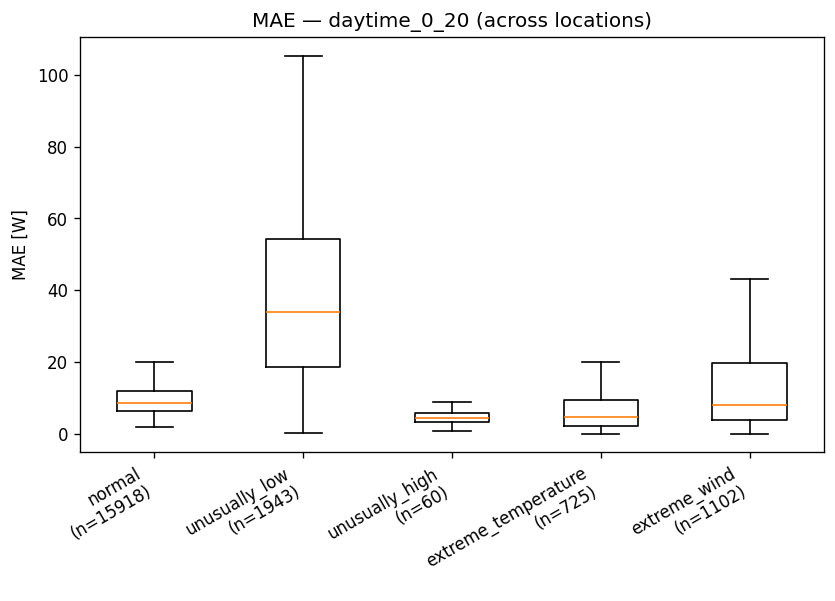

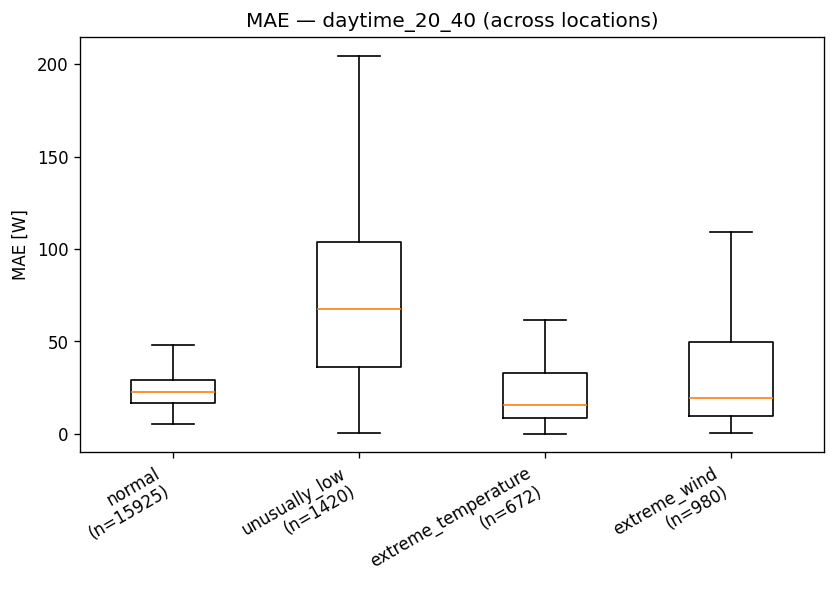

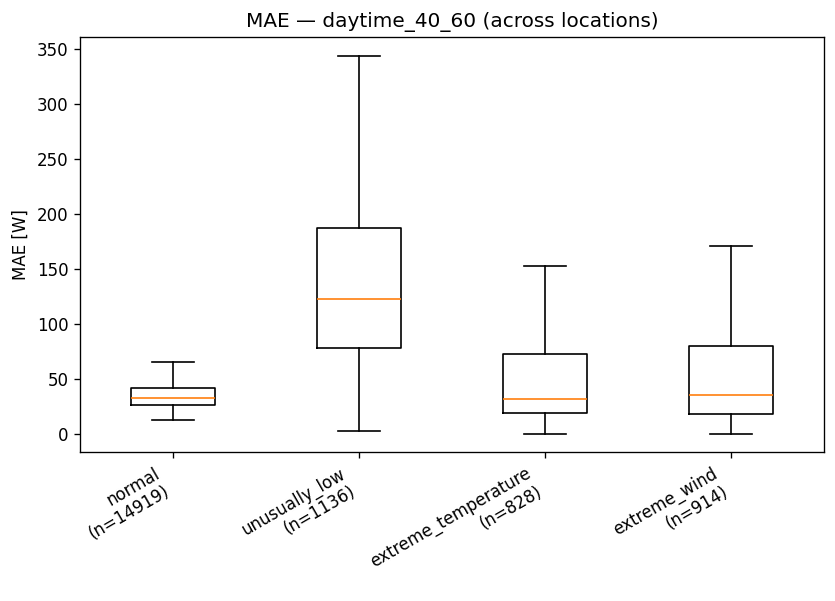

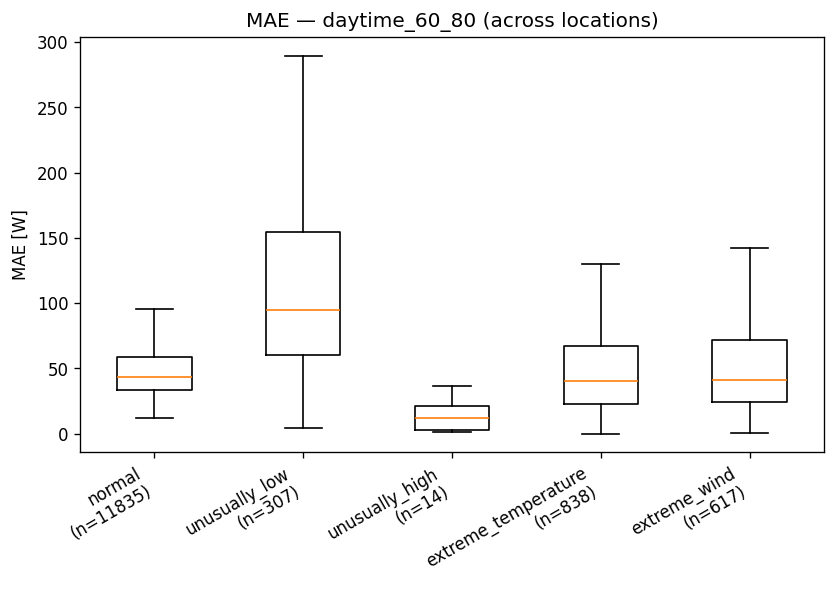

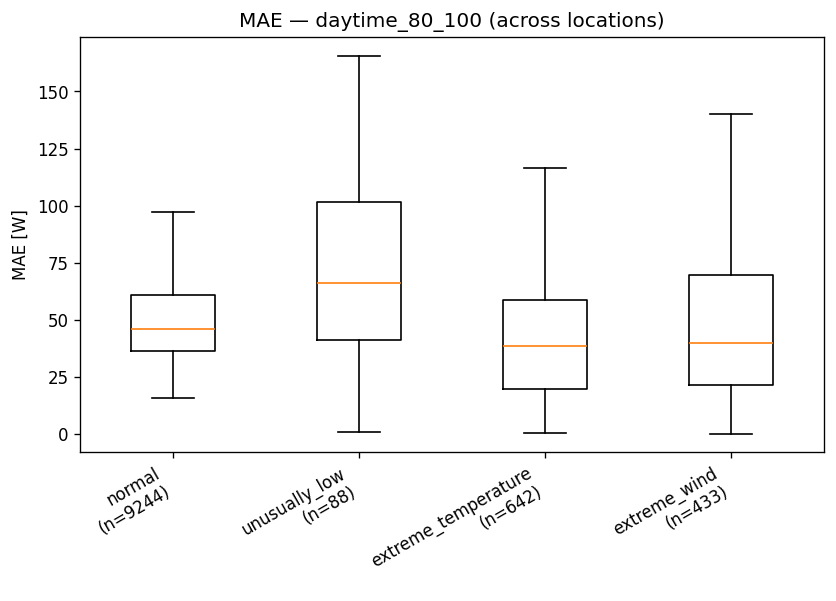

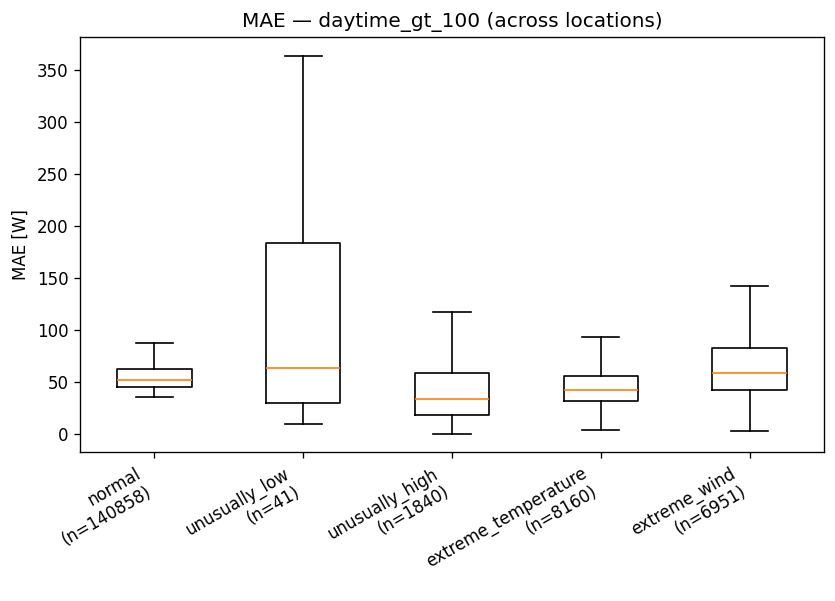

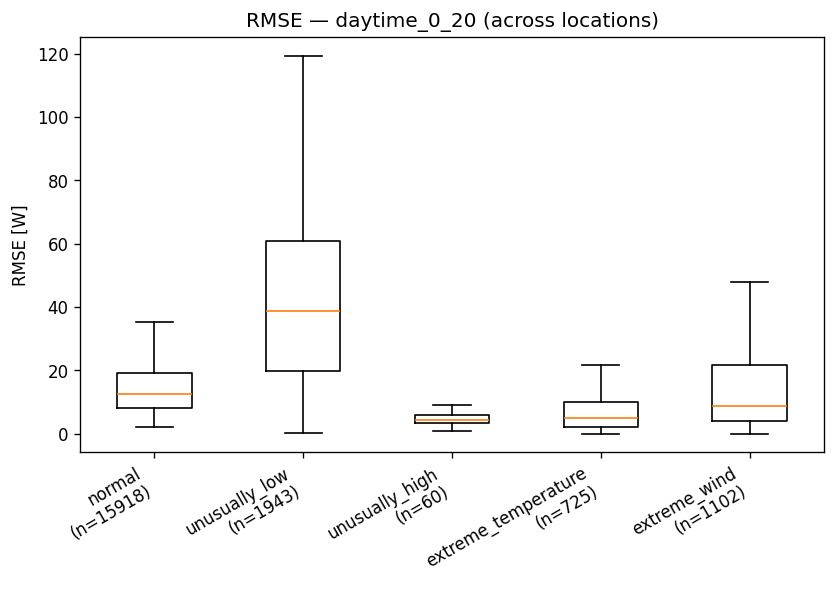

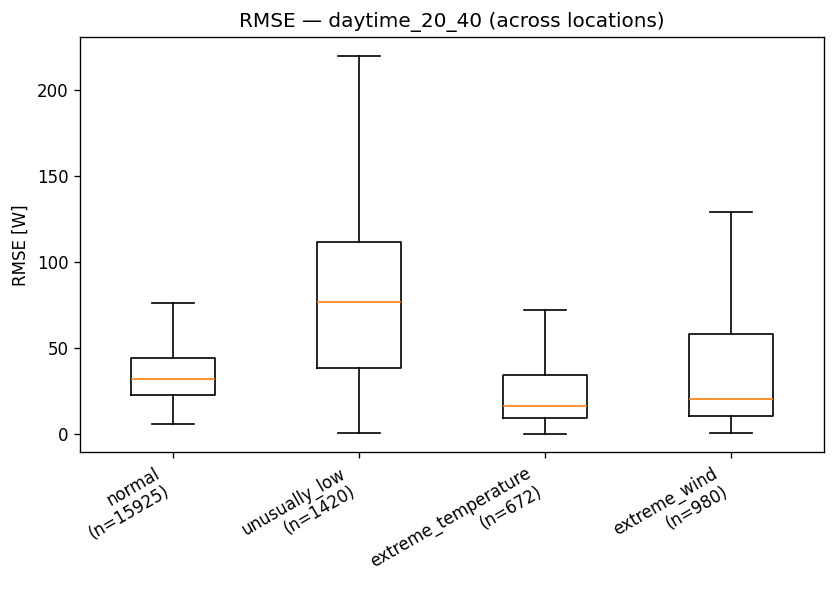

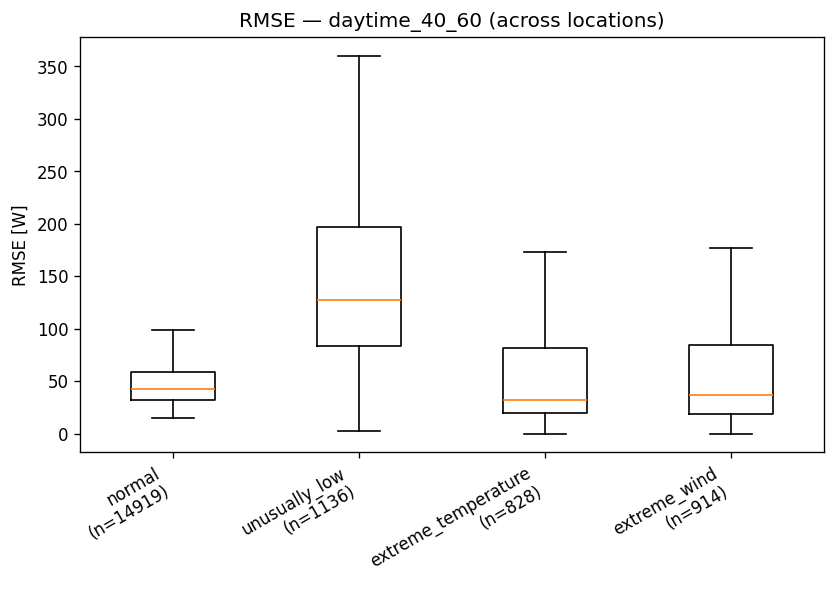

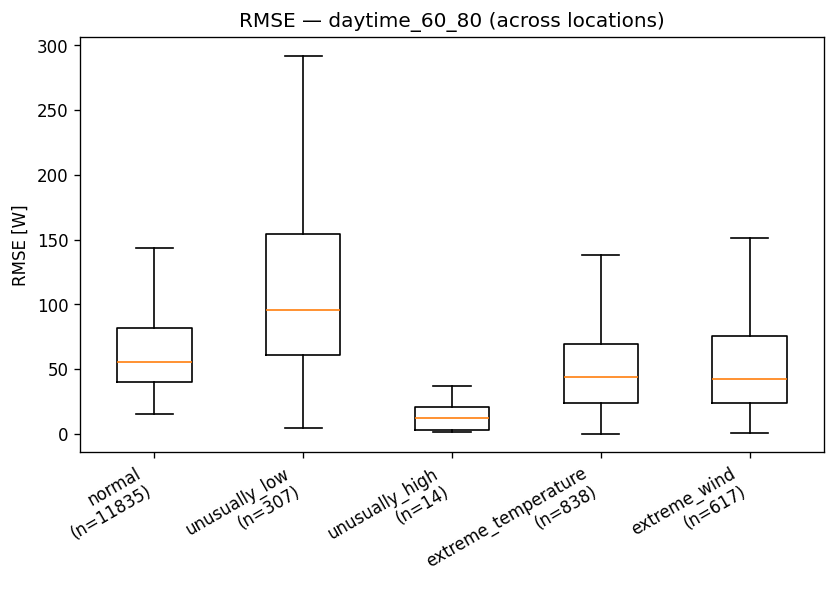

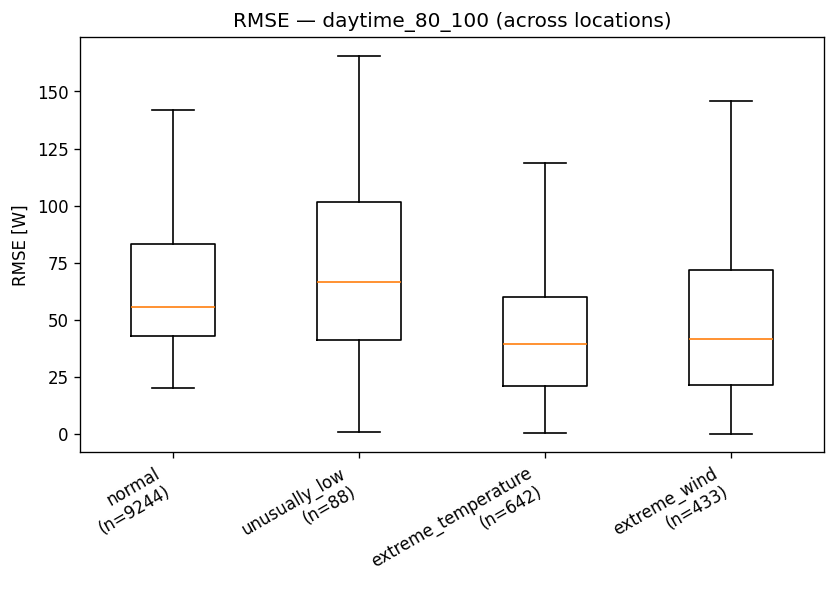

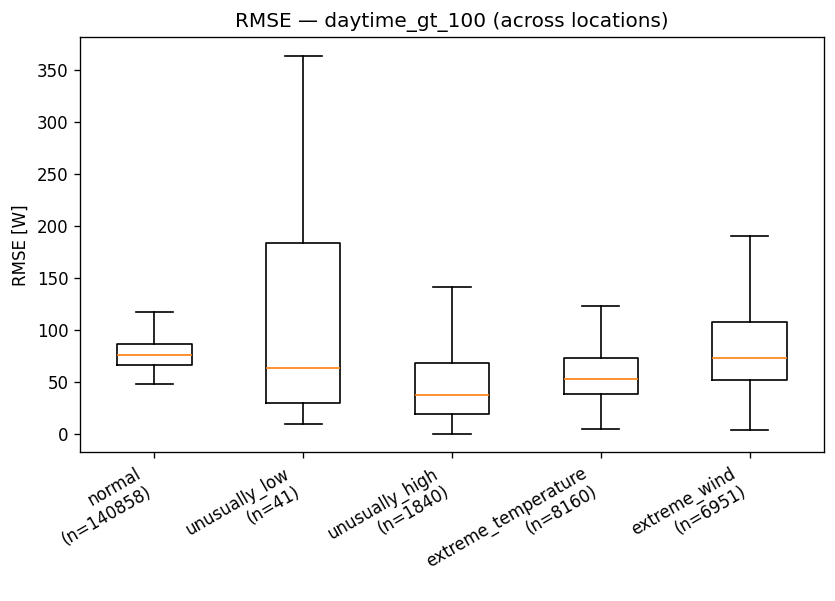

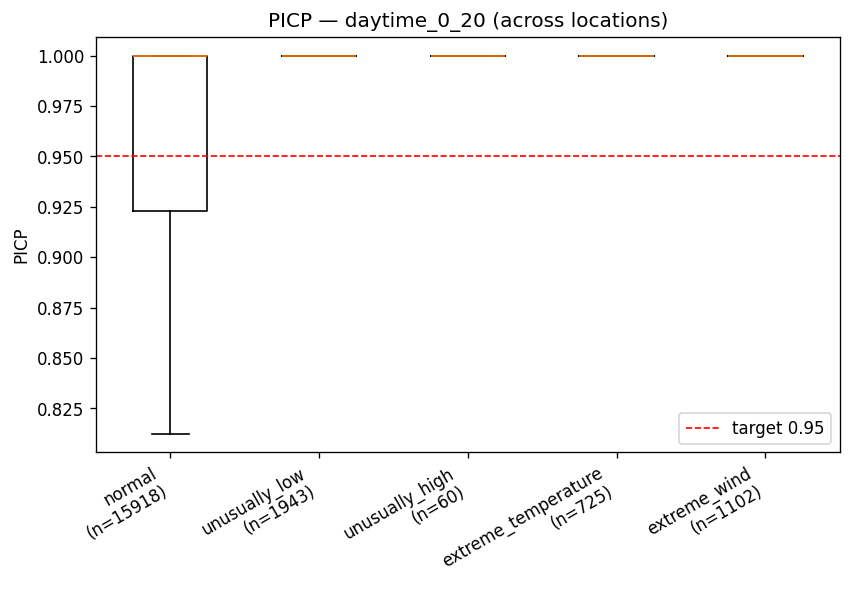

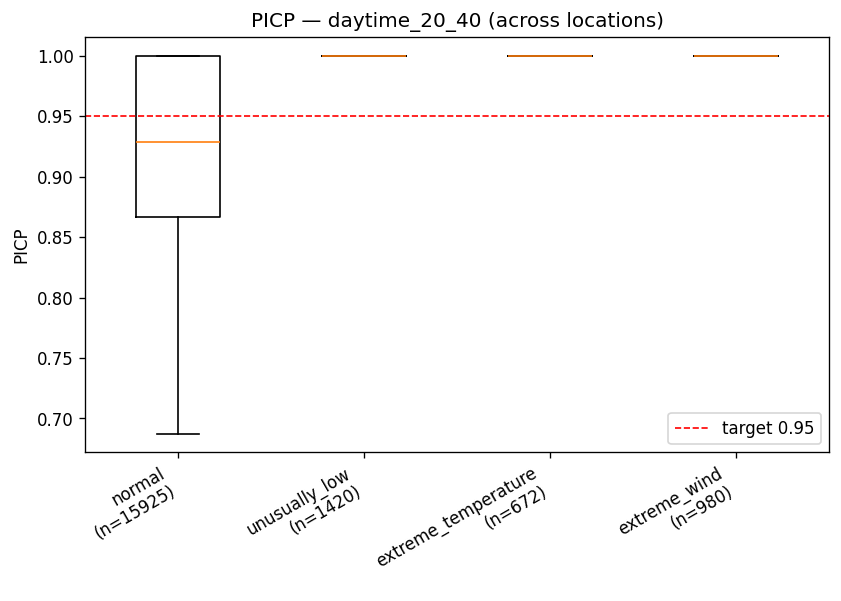

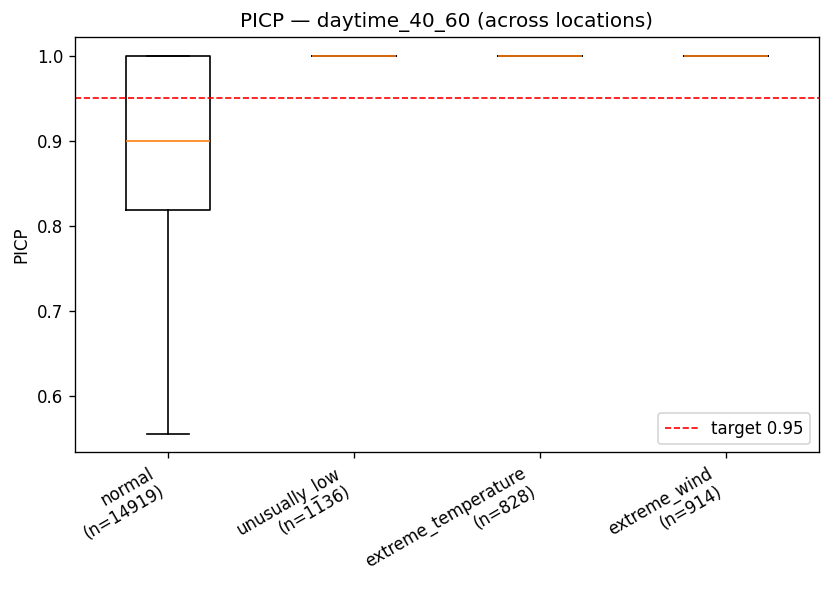

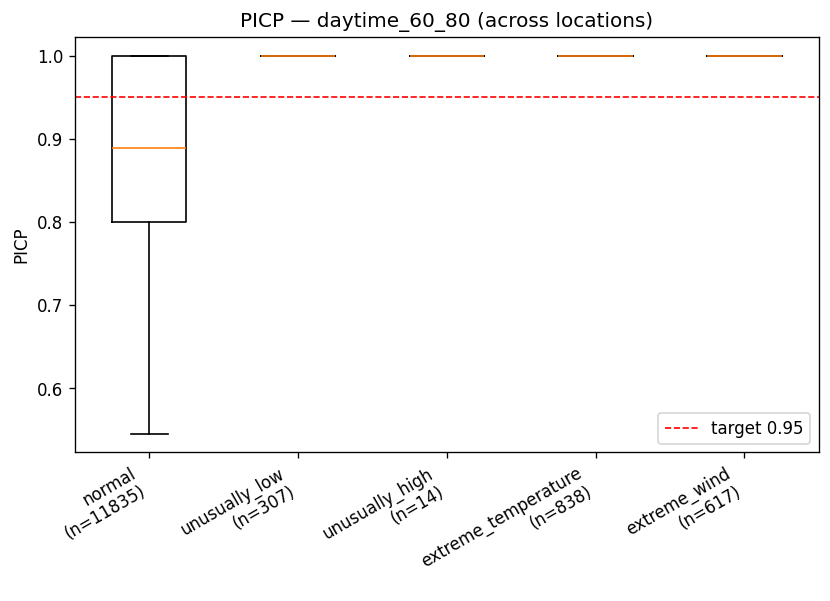

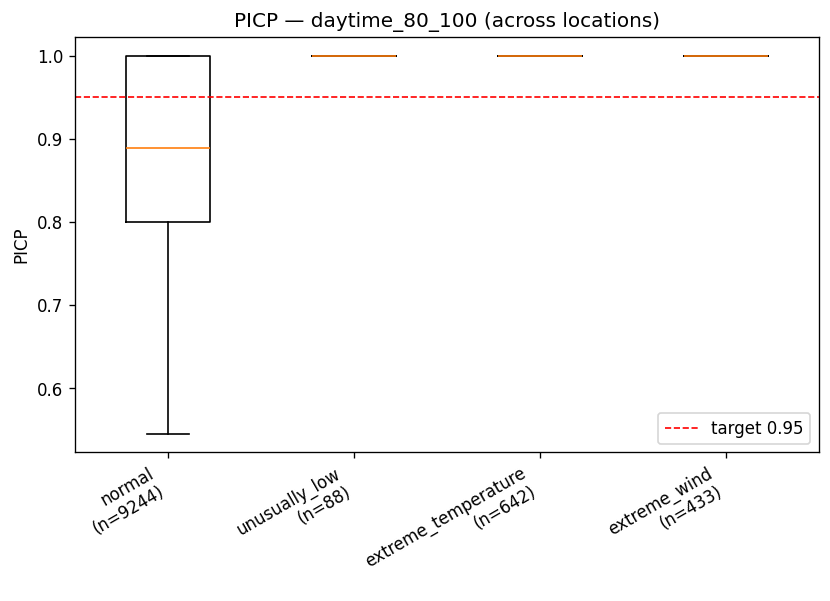

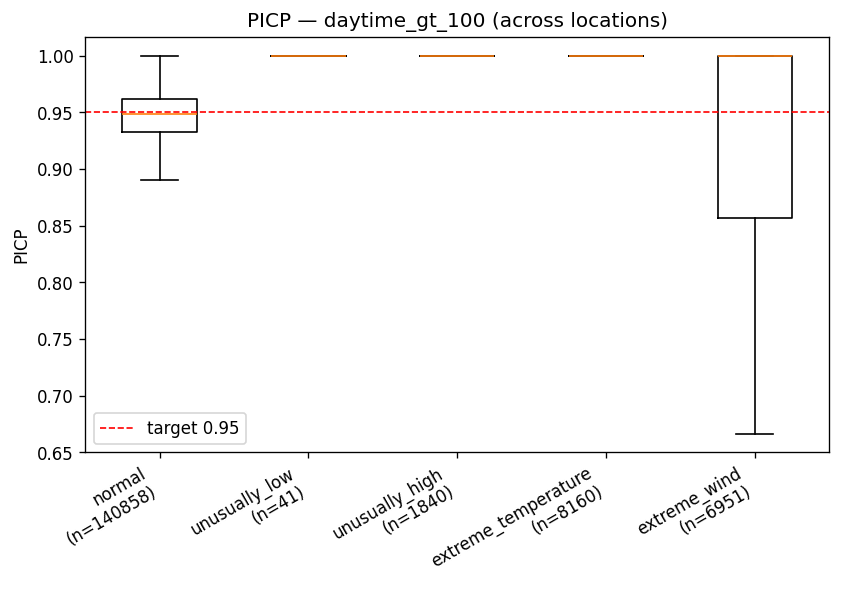

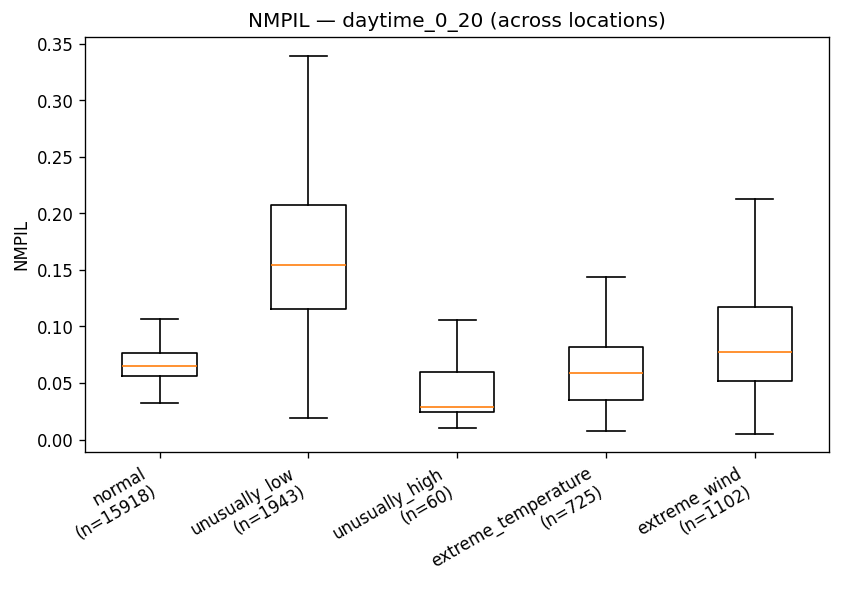

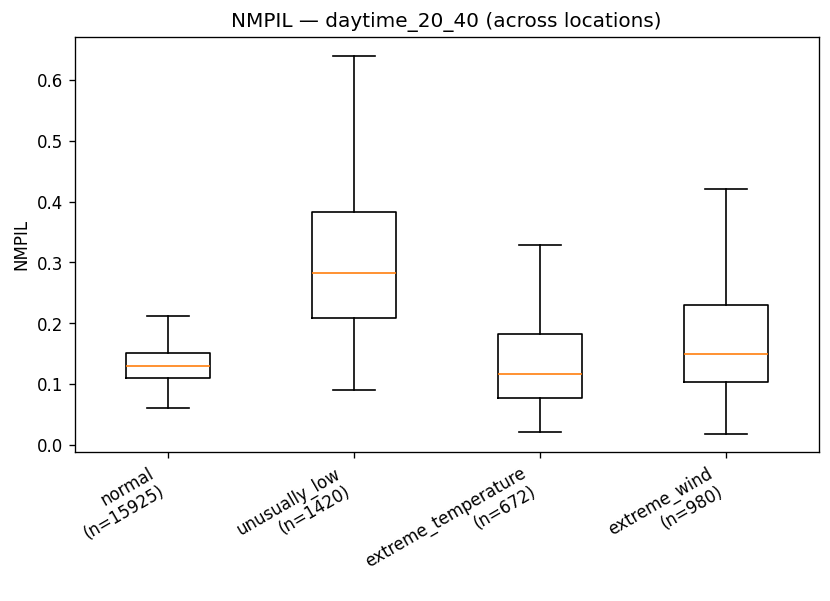

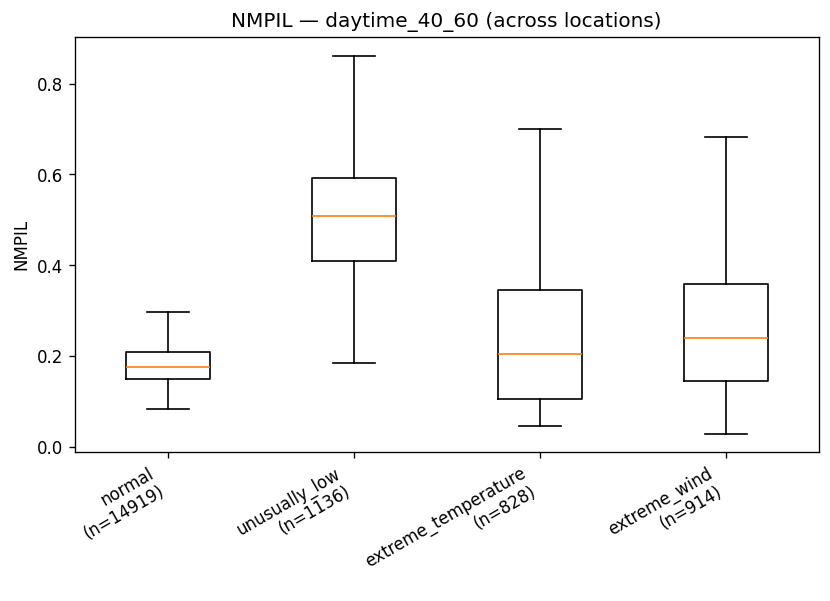

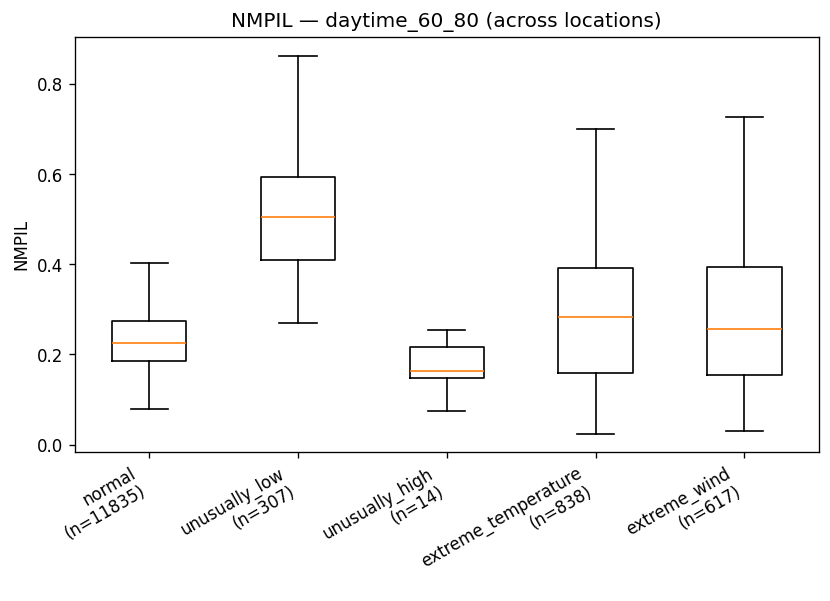

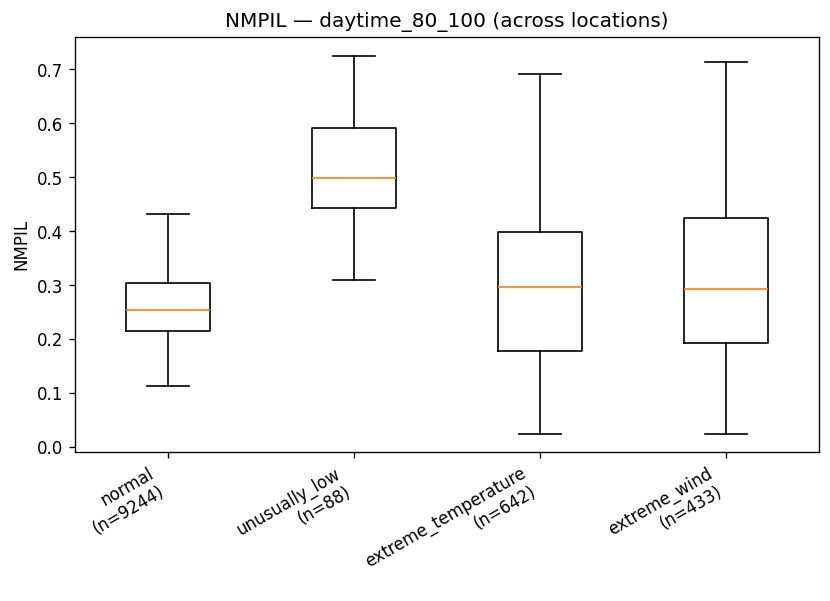

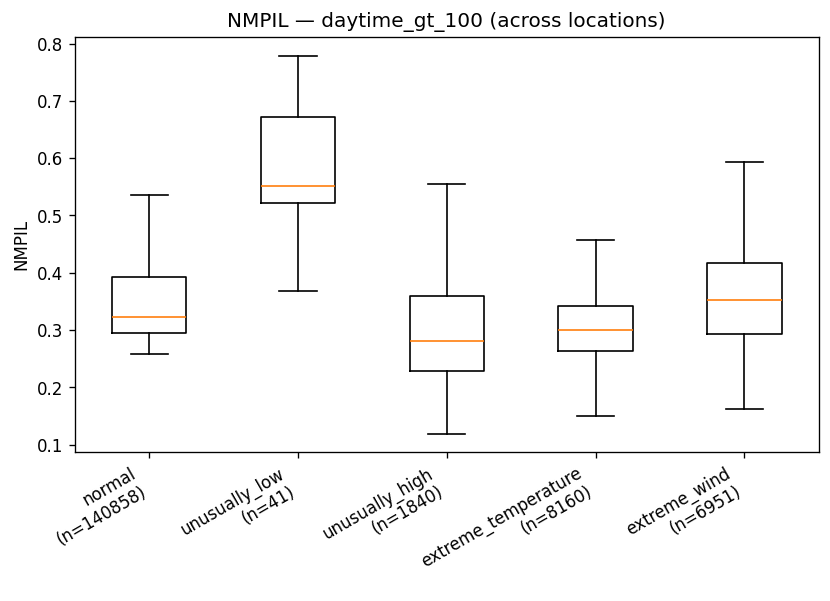

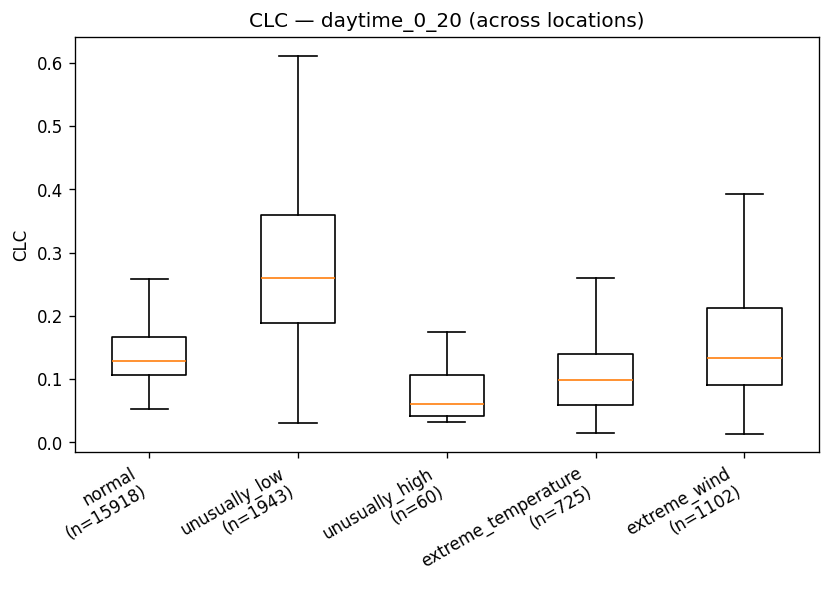

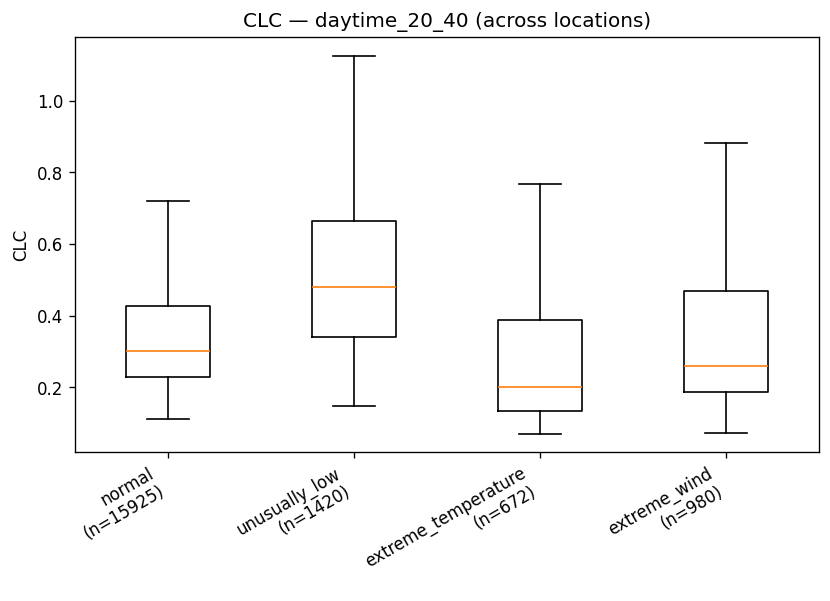

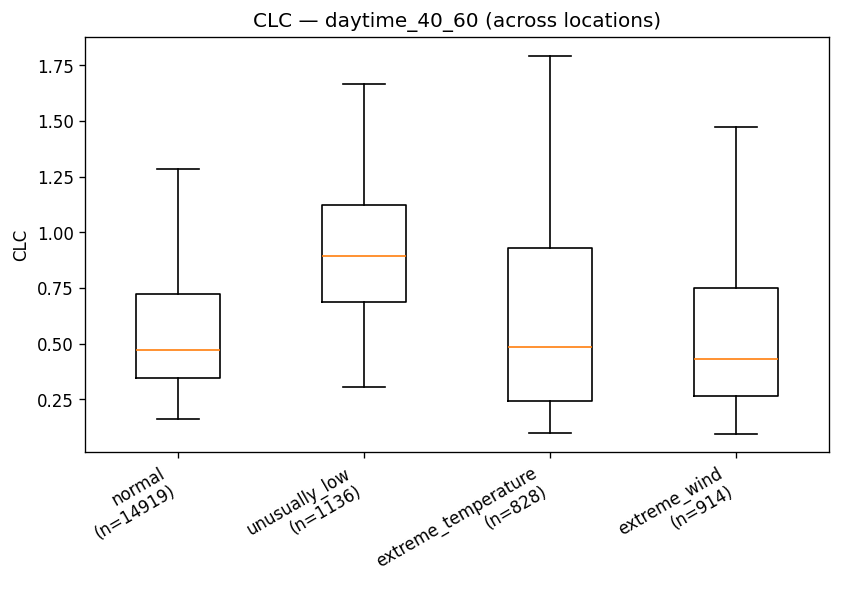

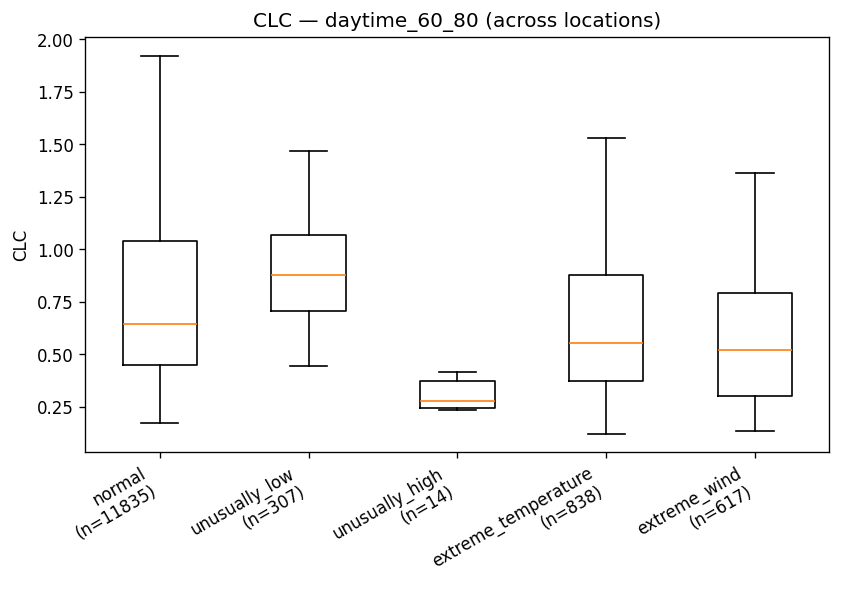

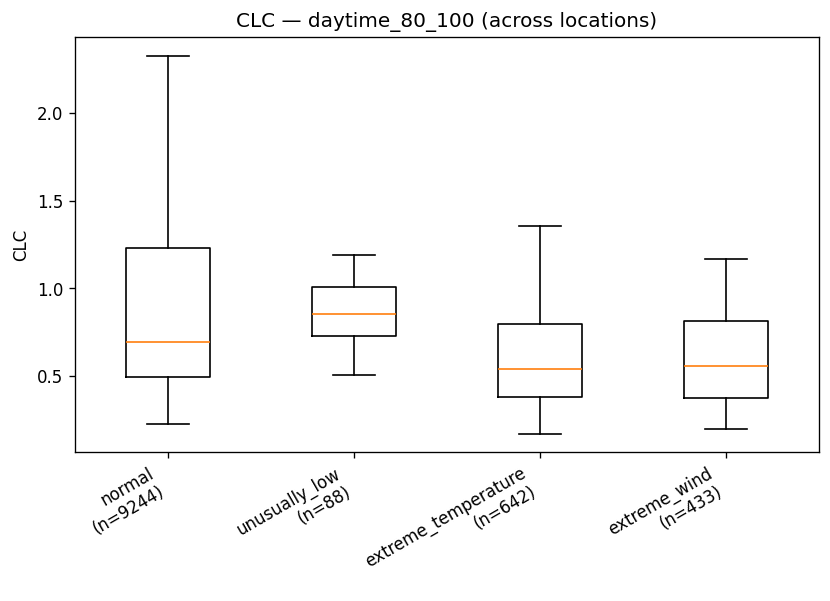

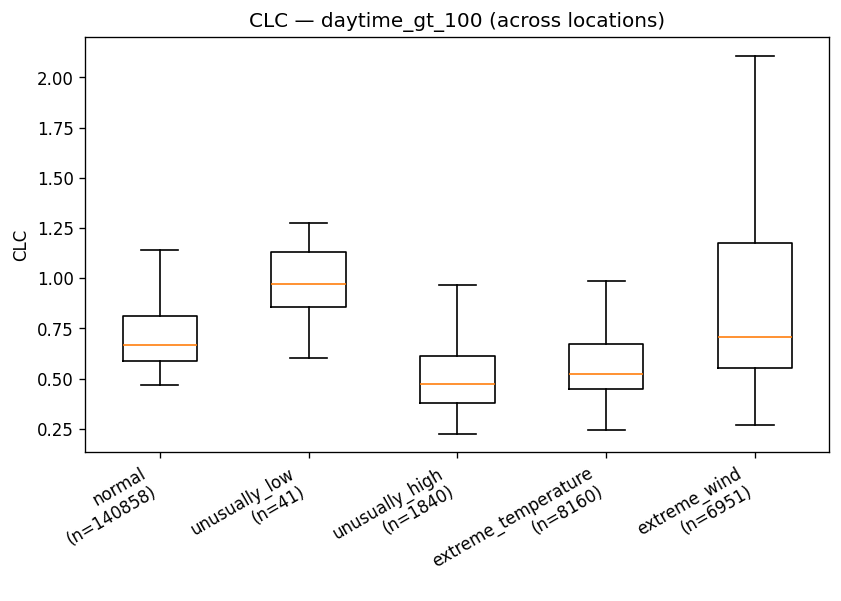

In [12]:
if figure_paths:
    from IPython.display import Image, display
    for path in figure_paths.values():
        display(Image(filename=str(path)))

## 7. W&B sweep (optional)

In [13]:
sweep_parameters = {
    'n_sde_steps': {'values': [4, 6]},
    'sigma_max': {'values': [0.3, 0.5]},
    'ood_noise_std': {'values': [0.05, 0.1]},
}
sweep_config = pipe.make_sweep_config(sweep_parameters)
sweep_config

{'program': 'scripts/run_pvgis_sde_sweep_member.py',
 'method': 'grid',
 'metric': {'name': 'posthoc/daytime_picp', 'goal': 'maximize'},
 'parameters': {'n_sde_steps': {'values': [4, 6]},
  'sigma_max': {'values': [0.3, 0.5]},
  'ood_noise_std': {'values': [0.05, 0.1]}}}

In [14]:
CREATE_SWEEP = False  # set True to register the sweep on W&B
if CREATE_SWEEP:
    import wandb
    sweep_id = wandb.sweep(sweep_config, project=pipe.WANDB_PROJECT, entity=pipe.WANDB_ENTITY)
    print('sweep_id:', sweep_id)
    print('wandb agent ' + pipe.WANDB_ENTITY + '/' + pipe.WANDB_PROJECT + '/' + str(sweep_id))
else:
    print('Set CREATE_SWEEP=True to register. The agent runs the program in sweep_config:')
    print('  ' + pipe.SWEEP_MEMBER_SCRIPT)
    print('  wandb agent ' + pipe.WANDB_ENTITY + '/' + pipe.WANDB_PROJECT + '/<sweep_id>')

Set CREATE_SWEEP=True to register. The agent runs the program in sweep_config:
  scripts/run_pvgis_sde_sweep_member.py
  wandb agent albertopedalino-politecnico-di-torino/PhysiQ-PV/<sweep_id>


## 8. Log post-hoc results to W&B (optional)

Adds post-hoc scalars, figures and a compact artifact to the matching W&B run.
The sweep wrapper does this automatically per run.

In [15]:
LOG_TO_WANDB = True
if LOG_TO_WANDB:
    import wandb
    run = pipe.init_wandb_run_for_out_dir(wandb, out_dir, run_name=run_name)
    try:
        posthoc = pipe.log_posthoc_to_wandb(
            wandb, run, out_dir,
            figure_paths=figure_paths if 'figure_paths' in dir() else None,
        )
        print(posthoc['summary'])
        print('posthoc artifact uploaded:', posthoc['artifact_uploaded'])
    finally:
        run.finish()
else:
    print('LOG_TO_WANDB is False. posthoc summary preview:')
    if Path(out_dir, 'sharpness_overview.csv').exists():
        print(pipe.read_posthoc_summary(out_dir))

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/apedalino/.netrc.
wandb: Currently logged in as: albertopedalino (albertopedalino-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


{'posthoc/daytime_picp': 0.9336532881731504, 'posthoc/daytime_mpiw': 250.83259135103032, 'posthoc/daytime_nmpil': 0.2812465923447012, 'posthoc/normal_picp': 0.9331512617361448, 'posthoc/rare_extreme_picp': 0.9374651578665392, 'posthoc/unusually_low_picp': 0.9327271813934797, 'posthoc/gt100_picp': 0.9467223094396408}
posthoc artifact uploaded: True


posthoc/daytime_mpiw,▁
posthoc/daytime_nmpil,▁
posthoc/daytime_picp,▁
posthoc/gt100_picp,▁
posthoc/normal_picp,▁
posthoc/rare_extreme_picp,▁
posthoc/unusually_low_picp,▁
clc_gaussian/daytime,0.60611
clc_gaussian/extreme_peak_daytime,0.49121
clc_gaussian/global,0.25339
clc_gaussian/high_daytime,0.59081
